# Backpropagation Through Time

## Start with the problem: a late mistake may depend on an early event

An RNN reuses the same transition to update its hidden state at every step. If a prediction near the end of a sequence is wrong, an early input and several intervening transitions may have contributed. How can training tell the shared weights what to change?

Backpropagation through time (BPTT) draws the repeated transition as a computation graph and applies the chain rule backward through it. Gradients from every use of a shared parameter add together. The algorithm does not send information into the past during prediction; it uses the recorded forward computation to calculate derivatives during training.

This lesson follows a three-step numerical example completely: inputs, states, predictions, losses, backward signals, all parameter gradients, and a new prediction after an update. It also verifies truncated gradients, padding masks, and clipping. The examples are deliberately small and run on CPU without downloads. They establish calculation behavior, not performance on unseen sequences.

Read [Recurrent Neural Networks](21_Recurrent_Neural_Networks_Notes.ipynb) first, then run the [code companion](22_Backpropagation_Through_Time.ipynb) to check every result.

## See both directions of the unrolled graph

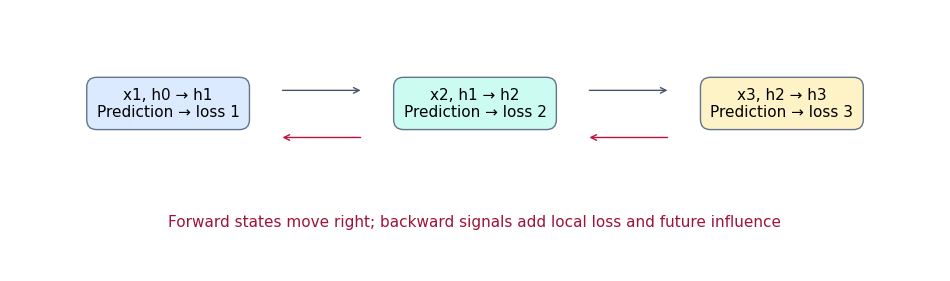

Each time step contributes a local loss. The same recurrent parameters receive contributions from all their uses; they are not separate weights at each step.

## Define the whole graph and the loss convention

Use one hidden value and one numeric prediction at each step:

$$z_t=wx_t+uh_{t-1}+b,\qquad h_t=\tanh(z_t),\qquad \hat y_t=vh_t+c.$$

The five parameters are input weight $w=0.7$, recurrent weight $u=0.6$, recurrent bias $b=0.1$, output weight $v=1.2$, and output bias $c=-0.1$. The initial state is fixed at $h_0=0.2$ for this teaching example. Inputs are $[1,-1,0.5]$, and targets are $[0.2,-0.1,0.4]$.

Use the mean half squared error across all three steps:

$$L=\frac{1}{2T}\sum_{t=1}^{T}(\hat y_t-y_t)^2,\qquad T=3.$$

Consequently the local output derivative is $(\hat y_t-y_t)/3$, not twice the error or the unscaled error. The half and mean are deliberate conventions; PyTorch's ordinary MSE loss has no half. Choosing sum versus mean scales all gradients and changes the effective size of an optimizer step.

This model makes a prediction at every step. A sequence classifier with only one final loss uses the same recurrence but has zero direct loss signals at the earlier steps. Those earlier states can still receive gradients from the future.

## Walk forward before differentiating

At step one, $z_1=0.7(1)+0.6(0.2)+0.1=0.92$, so $h_1=\tanh(0.92)\approx0.725897$. Its prediction is $1.2(0.725897)-0.1\approx0.771077$.

At step two, $z_2=0.7(-1)+0.6(0.725897)+0.1\approx-0.164462$, giving $h_2\approx-0.162995$ and prediction $-0.295594$.

At step three, $z_3=0.7(0.5)+0.6(-0.162995)+0.1\approx0.352203$, giving $h_3\approx0.338328$ and prediction $0.305994$.

| Step | Input | Pre-activation | Hidden state | Prediction | Target | Error |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 1.0 | 0.920000 | 0.725897 | 0.771077 | 0.2 | 0.571077 |
| 2 | -1.0 | -0.164462 | -0.162995 | -0.295594 | -0.1 | -0.195594 |
| 3 | 0.5 | 0.352203 | 0.338328 | 0.305994 | 0.4 | -0.094006 |

Square the three errors, add them, and divide by six: $L\approx0.062204$. The target affects the loss but is not passed into the recurrence. To calculate gradients, we retain the intermediate states and their computational relationships; merely retaining printed numbers would not retain an autograd graph.

## Add the local mistake to the signal from the future

Let $e_t=\hat y_t-y_t$ and $\delta_t=\partial L/\partial z_t$. The output's local derivative is $e_t/T$. At a hidden state there are two outgoing paths: its current prediction and the next recurrent step. Their loss sensitivities add:

$$\frac{\partial L}{\partial h_t}=v\frac{e_t}{T}+u\delta_{t+1},\qquad
\delta_t=\left(v\frac{e_t}{T}+u\delta_{t+1}\right)(1-h_t^2).$$

Set $\delta_{T+1}=0$ because there is no later step. The factor $1-h_t^2$ is the local tanh derivative. Calculate backward in the order step three, step two, step one:

| Step (reverse order) | Direct hidden signal v × error / 3 | Future signal u × next delta | Tanh slope | Delta |
| --- | --- | --- | --- | --- |
| 3 | -0.037603 | 0.000000 | 0.885534 | -0.033298 |
| 2 | -0.078237 | -0.019979 | 0.973433 | -0.095607 |
| 1 | 0.228431 | -0.057364 | 0.473073 | 0.080927 |

For example, at step two the direct signal is approximately $1.2(-0.195594)/3=-0.078237$. The future signal is $0.6\delta_3\approx-0.019985$. Add them first, then multiply by the step-two tanh slope. Ignoring the future contribution would train only the immediate prediction and miss how this state affected the final one.

The initial-state sensitivity is $\partial L/\partial h_0=u\delta_1$. It is useful for verifying the graph, although $h_0$ is fixed rather than optimized in this example. In a vector RNN, the future term becomes a recurrent-matrix transpose times the next preactivation gradient, and the tanh derivative is applied elementwise.

## Sum the contributions to every shared parameter

Each parameter is used at all three steps. The chain rule therefore gives

$$\frac{\partial L}{\partial w}=\sum_t\delta_t x_t,\quad
\frac{\partial L}{\partial u}=\sum_t\delta_t h_{t-1},\quad
\frac{\partial L}{\partial b}=\sum_t\delta_t,$$

$$\frac{\partial L}{\partial v}=\sum_t\frac{e_t}{T}h_t,\quad
\frac{\partial L}{\partial c}=\sum_t\frac{e_t}{T}.$$

The recurrent weight multiplies the **previous** state, not the current one. Its step-one contribution uses $h_0=0.2$. The output weights use direct output-loss signals because their influence on later states is absent in this model: predictions are not fed back as inputs.

| Step | Input-weight contribution | Recurrent-weight contribution | Bias contribution | Output-weight contribution | Output-bias contribution |
| --- | --- | --- | --- | --- | --- |
| 1 | 0.080927 | 0.016185 | 0.080927 | 0.138181 | 0.190359 |
| 2 | 0.095607 | -0.069401 | -0.095607 | 0.010627 | -0.065198 |
| 3 | -0.016649 | 0.005427 | -0.033298 | -0.010602 | -0.031335 |

Adding each column gives gradients approximately $[0.159885,-0.047788,-0.047979,0.138206,0.093826]$ for $[w,u,b,v,c]$. Contributions can reinforce or cancel. Sharing a weight does not mean averaging its uses again: the loss's division by three is already included in the local output derivatives.

For vector states, the corresponding input-weight contribution is an outer product between the preactivation gradient and the current input. The recurrent-weight contribution is an outer product with the previous hidden state. Summing over time and, as defined by the loss, over examples produces the gradient of each shared matrix.

## Check derivatives by changing the actual objective slightly

A second verification method perturbs one parameter by a small positive and negative amount and recalculates the complete forward loss. The central difference `(L(theta + epsilon) - L(theta - epsilon)) / (2 × epsilon)` should agree with its gradient when epsilon is suitable and the function is smooth.

We use double precision and epsilon `1e-6`, holding all other parameters fixed. This independently checks the unrolled computation's derivative, rather than comparing two copies of the same handwritten formula. Too large an epsilon measures a nonlocal change; too small an epsilon suffers floating-point cancellation.

A crucial distinction appears later: when a hidden state is detached, autograd differentiates a deliberately cut graph. Finite differences of the original full forward function still measure its full mathematical derivative, so they need not match a truncated gradient. That disagreement is expected when truncation is intentional.

## Apply one update, then redo the forward calculation

Backpropagation produces derivatives, not new parameter values. Plain SGD with rate $\eta=0.1$ separately applies $\theta'=\theta-0.1\nabla_\theta L$.

For the five parameters, this gives approximately:

- $w'=0.7-0.1(0.159885)=0.684012$.
- $u'=0.6-0.1(-0.047788)=0.604779$.
- $b'=0.1-0.1(-0.047979)=0.104798$.
- $v'=1.2-0.1(0.138206)=1.186179$.
- $c'=-0.1-0.1(0.093826)=-0.109383$.

All five gradients came from the same old forward pass. Only after changing the parameters do we recompute every state and prediction from the same fixed initial state. Reusing old hidden values would not evaluate the updated recurrent model.

The code prints the new predictions and loss and verifies that this particular small step improves the objective. A larger rate could increase it. Improvement on this one sequence verifies an update, not generalization.

## Inspect the result of the shared-weight update

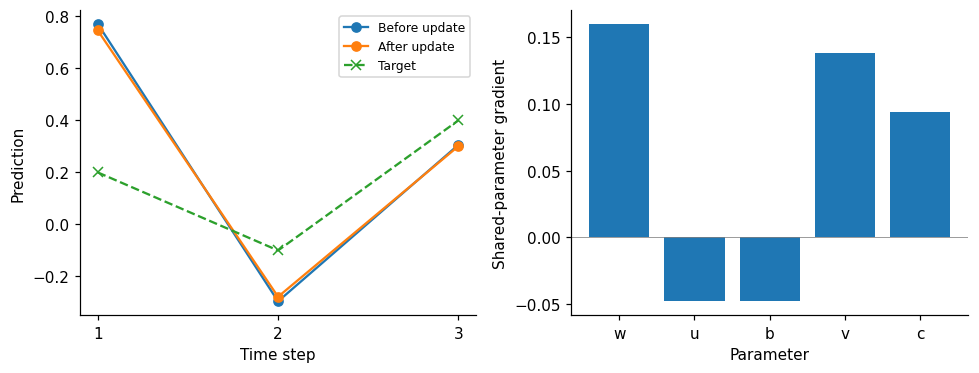

One SGD step changes the predictions at all three times because each parameter is reused. The bars show the complete gradient after summing time-step contributions.

## Chunking and truncation are different operations

Processing a sequence in chunks does not by itself shorten the gradient path. If the hidden state keeps its graph, later losses can still reach earlier chunks and the full gradient is unchanged. Detaching the carried state keeps its value but cuts that path.

We split our three steps into a two-step chunk followed by a one-step chunk. With weights fixed, both full and detached versions produce identical forward states, predictions, and loss values. In the truncated graph, the final loss treats the carried state from step two as a constant. It can update weights used in step three, but cannot send its recurrent contribution back through steps one and two.

The earlier steps still have their own losses in our all-step objective, so their direct learning signals remain. With a final-only loss, detaching after step two makes the gradient to the first two input values zero. The code checks both cases explicitly.

This demonstration accumulates one whole-sequence objective and changes no weights between chunks, isolating the effect of detachment. A practical truncated-BPTT loop often also performs optimizer steps per chunk; that adds another difference because later chunks use newer weights with a carried state computed under earlier weights. Loss normalization across unequal chunk lengths is another explicit choice. Truncation trades memory and computation for a shorter credit-assignment horizon; it is not exactly the full gradient.

## See which gradients change when history is cut

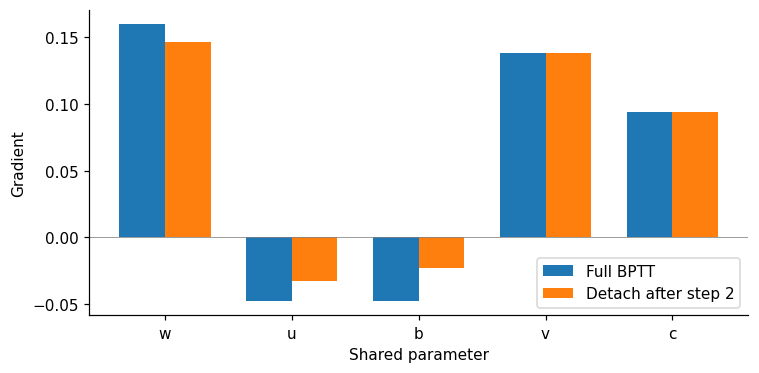

Detaching after step two changes recurrent-parameter derivatives while leaving the forward predictions and this model's output-head derivatives unchanged.

## Mask padding and choose the loss denominator deliberately

A padded batch contains storage positions that are not real time steps. For one length-three sequence and one length-two sequence, there are five valid predictions even if the rectangular tensor contains six slots.

For a mean half squared error per valid step, use

$$L=\frac{\sum_{n,t}M_{n,t}(\hat y_{n,t}-y_{n,t})^2}{2\sum_{n,t}M_{n,t}},$$

where $M$ is one on valid positions. Dividing by six after zeroing one padded error would incorrectly shrink the intended five-step average. Averaging per-sequence means equally is a different valid objective that gives each sequence equal total weight; it is not generally the same as weighting each valid time step equally.

We also preserve the last valid hidden state after a sequence ends. A mask on the loss alone does not stop padded inputs from changing a final state that might later be used by a classifier. Here `where(active, candidate_state, previous_state)` blocks those updates. Packing sequences, as in the RNN lesson, is another way to avoid recurrent work on padding.

The code compares the masked batch objective with the sum of independently computed valid-step losses divided by five, verifies zero derivative to padding, and checks that changing a padded input does not change valid outputs or final states.

## Clip the gradient after computing it, not instead of computing it

A long recurrent graph multiplies many local sensitivities. These can shrink toward zero or grow large, depending on states and recurrent weights. BPTT calculates these sensitivities; it does not ensure they are well conditioned.

Global norm clipping rescales the combined parameter gradient when its Euclidean norm exceeds a threshold $c$. For gradient $g$, the idealized rule is $g'=g\min(1,c/\|g\|)$. All components use one common scale, preserving direction when clipping is active. PyTorch uses a small stabilizing term in the denominator.

We apply a deliberately small threshold 0.1 to the five-parameter gradient so the effect is visible. Clip after `backward()` and before `optimizer.step()`. This bounds the gradient passed to the optimizer; with adaptive optimizer states it is not a universal bound on the eventual parameter movement.

Clipping does not make a vanished signal informative, restore paths cut by detachment, or fix an unsuitable sequence model. Gated RNNs and other sequence architectures address additional aspects of learning long dependencies.

## Read the verified calculations

All 8 code cells and embedded assertions passed in a fresh in-process CPU kernel. The manual recurrent derivatives matched autograd for all five parameters, all input steps, and the initial hidden state. Central finite differences agreed within 2.27e-11. One full-gradient SGD update reduced the sequence objective from 0.062204 to 0.056582.

Chunking without detachment preserved the full gradient. Detachment preserved the forward result but cut the expected backward paths; with final-only loss the earlier input gradients became zero. Masked batching matched independent valid-step calculations and produced zero padding gradients. Global clipping used a common scale and bounded the combined norm. These are verified learning mechanisms on constructed examples, not held-out performance claims.

## Keep the training graph aligned with the sequence problem

For independent examples, reset hidden states rather than carrying history across shuffled rows. For a continuous stream, define when state should persist, where gradients should stop, and when weights should update. These are data and training decisions, not interchangeable boilerplate.

A normal update clears old parameter gradients, constructs a forward graph, computes the intended loss reduction, backpropagates, optionally clips, and steps the optimizer. PyTorch accumulates parameter gradients by default; failing to clear them changes the update. Reusing a freed graph requires recomputation or deliberate graph retention, not an automatic `retain_graph=True` everywhere.

Calling `.item()`, converting through NumPy, or detaching an intermediate before using it in a loss breaks the intended gradient path. Detaching for logging is appropriate; detaching for truncated BPTT is also appropriate when intentional. Resetting a hidden state to zero is stronger than detaching: it discards the state value as well as its history.

The worked example explains what the ANN learns from: current prediction errors plus their downstream consequences. Full BPTT preserves every recorded dependency, truncation deliberately limits credit assignment, and masking preserves the distinction between real sequence events and storage padding. None of these calculation checks replaces evaluation on new sequences.